In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from scipy.stats import chi2_contingency, mannwhitneyu, spearmanr

TARGET = "CKD (1-yes, 0-no)"

In [2]:
#  1. Load the full longitudinal dataset
df = pd.read_csv("DiabeticCKD_dataset.csv")
df.columns = df.columns.str.strip()


In [3]:
#  2. Build lifestyle / treatment adherence features
# Positive / recommended behaviours (1 = good)
df["Diet_follow"] = df["Follow suggested Diet (1-yes, 0-no)"]
df["Med_follow"]  = df["Take Medicine for Diabetes (1-yes, 0-no)"]
df["Insulin_use"] = df["Take Insulin (1-yes, 0-no)"]
df["Sleep_good"]  = df["Sleep (1-sufficient, 0-insufficient)"]
df["Water_good"]  = df["Water Consumption (1-sufficient, 0-insufficient)"]
df["Walk_good"]   = df["Walk Regularly (1-yes, 0-no)"]

# Harmful behaviours, reversed so that 1 = good (behaviour absent)
df["No_Smoke"]       = 1 - df["Smoke (1-yes, 0-no)"]
df["No_Zarda"]       = 1 - df["Zarda, Betel Leaf (1-yes, 0-no)"]
df["Low_Painkiller"] = 1 - df["Pain killer (1-yes, 0-no)"]

# Calorie intake: min-max scaled to 0-1 and reversed so lower intake scores higher
cal = df["Calorie Intake (per day)"]
df["Calorie_score"] = 1 - (cal - cal.min()) / (cal.max() - cal.min())
df["Calorie_score"] = df["Calorie_score"].clip(0, 1)

feature_cols = [
    "Diet_follow", "Med_follow", "Insulin_use",
    "Sleep_good", "Water_good", "Walk_good",
    "No_Smoke", "No_Zarda", "Low_Painkiller",
    "Calorie_score"
]
df["LifestyleScore"] = df[feature_cols].sum(axis=1)

In [4]:
#  3. Define adherence groups
df["HighAdherence"] = (df["LifestyleScore"] >= 6).astype(int)

print(f"LifestyleScore: mean {df['LifestyleScore'].mean():.3f} "
      f"(SD {df['LifestyleScore'].std():.3f})")
print(f"High adherence: {int(df['HighAdherence'].sum())} observations "
      f"({df['HighAdherence'].mean()*100:.2f}%)")


LifestyleScore: mean 7.199 (SD 1.385)
High adherence: 3062 observations (76.55%)


In [5]:
# CKD PREVALENCE ACROSS THE DIABETIC TRAJECTORY

ckd_trend_all = (
    df.groupby("Diabetic Year")[TARGET]
      .agg(["mean", "size"])
      .reset_index()
      .rename(columns={"mean": "CKD_rate", "size": "N"})
)
trend_pivot = (
    df.groupby(["Diabetic Year", "HighAdherence"])[TARGET]
      .mean()
      .unstack()
)
print("\n" + "=" * 72)
print("CKD PREVALENCE BY DIABETIC YEAR AND ADHERENCE GROUP")
print("=" * 72)
print(f"{'Year':<7}{'Obs':>7}{'CKD (%)':>11}{'Low adh. (%)':>15}{'High adh. (%)':>16}")
for _, r in ckd_trend_all[ckd_trend_all["Diabetic Year"] <= 10].iterrows():
    yr = int(r["Diabetic Year"])
    low  = trend_pivot.loc[yr, 0] * 100 if 0 in trend_pivot.columns else np.nan
    high = trend_pivot.loc[yr, 1] * 100 if 1 in trend_pivot.columns else np.nan
    print(f"{yr:<7}{int(r['N']):>7}{r['CKD_rate']*100:>11.1f}"
          f"{low:>15.1f}{high:>16.1f}")



CKD PREVALENCE BY DIABETIC YEAR AND ADHERENCE GROUP
Year       Obs    CKD (%)   Low adh. (%)   High adh. (%)
1          217        0.0            0.0             0.0
2          231        0.4            0.0             0.6
3          250        0.8            1.8             0.5
4          259        2.3            2.9             2.1
5          272        7.4            8.9             6.9
6          299        9.0            8.0             9.4
7          308       11.7            8.2            12.6
8          318       15.4           12.0            16.5
9          323       18.0           14.3            19.0
10         330       23.3           24.7            22.9


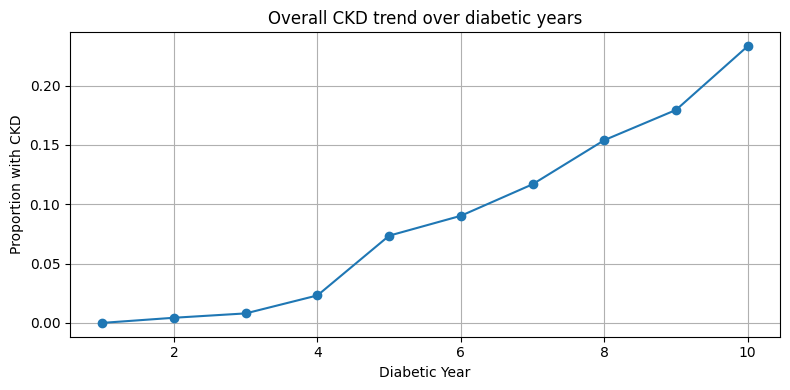

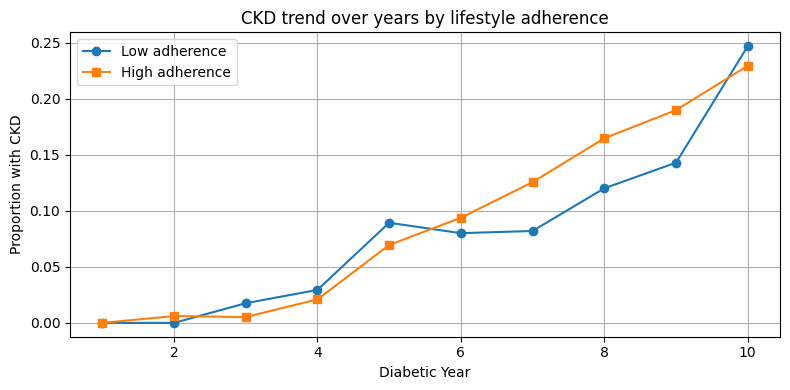

In [6]:
# overall trajectory
plt.figure(figsize=(8, 4))
sub = ckd_trend_all[ckd_trend_all["Diabetic Year"] <= 10]
plt.plot(sub["Diabetic Year"], sub["CKD_rate"], marker="o")
plt.xlabel("Diabetic Year")
plt.ylabel("Proportion with CKD")
plt.title("Overall CKD trend over diabetic years")
plt.grid(True)
plt.tight_layout()
plt.show()

# trajectory by adherence group
plt.figure(figsize=(8, 4))
pv = trend_pivot[trend_pivot.index <= 10]
if 0 in pv.columns:
    plt.plot(pv.index, pv[0], marker="o", label="Low adherence")
if 1 in pv.columns:
    plt.plot(pv.index, pv[1], marker="s", label="High adherence")
plt.xlabel("Diabetic Year")
plt.ylabel("Proportion with CKD")
plt.title("CKD trend over years by lifestyle adherence")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



In [8]:
# PATIENT-LEVEL ASSOCIATION TESTS (N = 400)

pre = pd.read_csv("CKD_preprocessed_patient_level.csv")
pre.columns = [c.strip() for c in pre.columns]

indicators = [
    ("Pain killer (1-yes, 0-no)","Pain killer use",1),
    ("Sleep (1-sufficient, 0-insufficient)","Sleep sufficiency",0),
    ("Walk Regularly (1-yes, 0-no)","Regular walking",0),
    ("Smoke (1-yes, 0-no)","Smoking",1),
    ("Water Consumption (1-sufficient, 0-insufficient)","Water consumption",0),
    ("Zarda, Betel Leaf (1-yes, 0-no)", "Zarda / betel leaf",1),
    ("Follow suggested Diet (1-yes, 0-no)","Diet adherence",0),
    ("Urination Properly (1-yes, 0-no)", "Proper urination",0),
    ("Take Insulin (1-yes, 0-no)","Insulin therapy",1),
    ("Heart Disease (1-yes, 0-no)","Heart disease",1),
    ("Urinary Infection (1-yes, 0-no)","Urinary infection",1),
    ("Hypertension (1-yes, 0-no)","Hypertension",1),
]

def stars(p):
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"

print("\n" + "=" * 78)
print("CKD PREVALENCE BY BINARY INDICATOR (N = 400), CHI-SQUARE TEST")
print("=" * 78)
print(f"{'Indicator':<24}{'Adverse (%)':>13}{'Favourable (%)':>17}{'p':>12}{'Sig.':>7}")
for col, label, adverse_is_one in indicators:
    rates = pre.groupby(col)[TARGET].mean() * 100
    adverse    = rates.get(1 if adverse_is_one else 0, np.nan)
    favourable = rates.get(0 if adverse_is_one else 1, np.nan)
    chi2, p, _, _ = chi2_contingency(pd.crosstab(pre[col], pre[TARGET]))
    print(f"{label:<24}{adverse:>13.1f}{favourable:>17.1f}{p:>12.4f}{stars(p):>7}")



CKD PREVALENCE BY BINARY INDICATOR (N = 400), CHI-SQUARE TEST
Indicator                 Adverse (%)   Favourable (%)           p   Sig.
Pain killer use                  60.8             40.0      0.0002    ***
Sleep sufficiency                53.9             40.9      0.0130      *
Regular walking                  37.4             51.4      0.0094     **
Smoking                          57.4             44.5      0.1049     ns
Water consumption                54.3             45.5      0.4118     ns
Zarda / betel leaf               49.0             45.3      0.5927     ns
Diet adherence                   44.6             46.9      0.7715     ns
Proper urination                 64.5             42.9      0.0027     **
Insulin therapy                  53.6             29.5      0.0000    ***
Heart disease                    63.0             40.1      0.0001    ***
Urinary infection                66.0             39.9      0.0000    ***
Hypertension                     42.9            

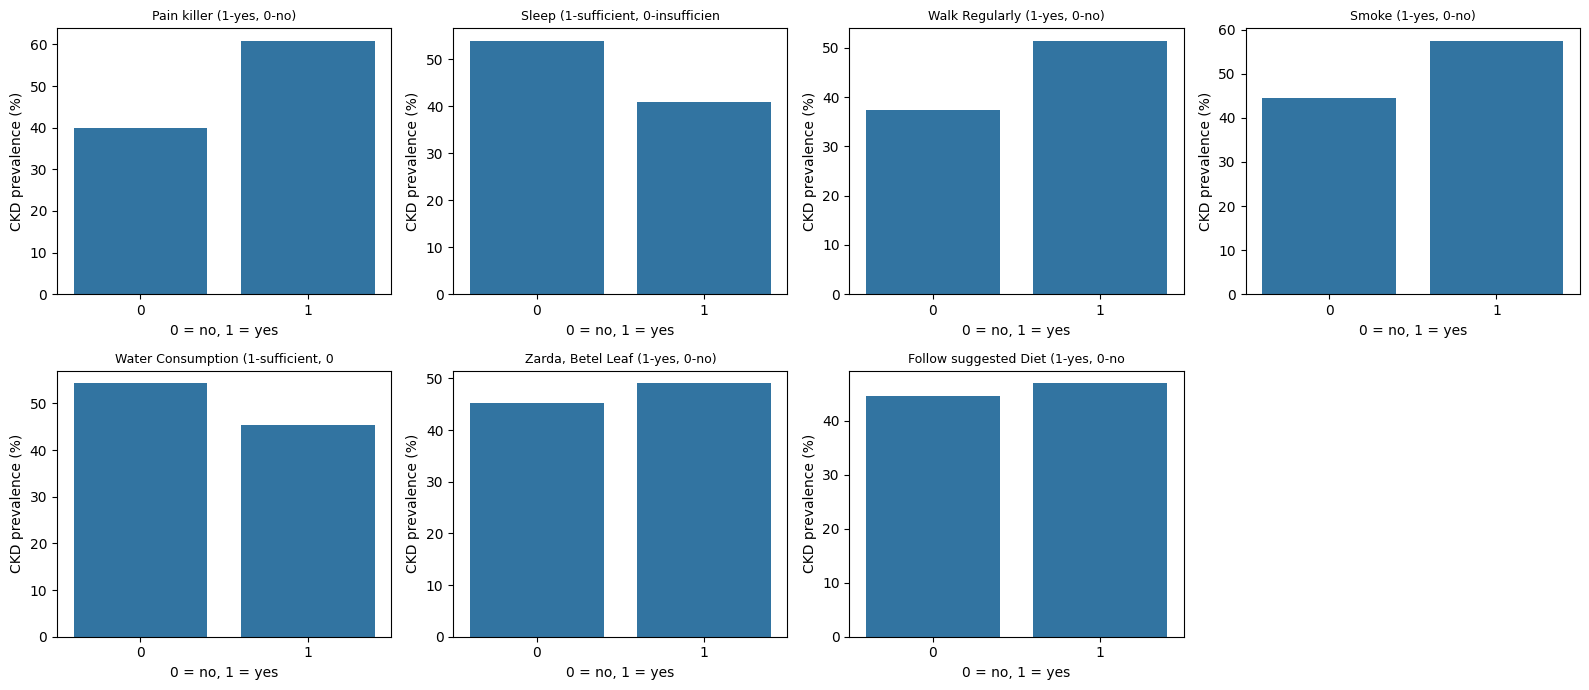

In [9]:
# CKD rate by individual lifestyle behaviour
lifestyle_cols = [c for c, _, _ in indicators[:7]]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), lifestyle_cols):
    tmp = (pre.groupby(col)[TARGET].mean() * 100).reset_index()
    sns.barplot(data=tmp, x=col, y=TARGET, ax=ax)
    ax.set_title(col[:34], fontsize=9)
    ax.set_ylabel("CKD prevalence (%)")
    ax.set_xlabel("0 = no, 1 = yes")
for ax in axes.ravel()[len(lifestyle_cols):]:
    ax.axis("off")
plt.tight_layout()
plt.show()


In [10]:
# CONTINUOUS VARIABLES BY CKD STATUS (Mann-Whitney U)

continuous = ["BMI", "Weight (kg)", "Calorie Intake (per day)", "Diabetic Year",
              "Age", "Weight_Change_From_Avg", "Comorbidity_Count",
              "Poor_Lifestyle_Score", "Diabetic_Duration_x_Insulin",
              "BMI_x_Hypertension"]

print("\n" + "=" * 84)
print("CONTINUOUS VARIABLES BY CKD STATUS (N = 400), MANN-WHITNEY U")
print("=" * 84)
print(f"{'Variable':<30}{'No CKD: M (SD)':>22}{'CKD: M (SD)':>22}{'p':>10}{'Sig.':>6}")
for c in continuous:
    a = pre.loc[pre[TARGET] == 0, c]
    b = pre.loc[pre[TARGET] == 1, c]
    _, p = mannwhitneyu(a, b)
    print(f"{c:<30}{f'{a.mean():.2f} ({a.std():.2f})':>22}"
          f"{f'{b.mean():.2f} ({b.std():.2f})':>22}{p:>10.4f}{stars(p):>6}")



CONTINUOUS VARIABLES BY CKD STATUS (N = 400), MANN-WHITNEY U
Variable                              No CKD: M (SD)           CKD: M (SD)         p  Sig.
BMI                                     24.03 (3.86)          25.25 (3.58)    0.0006   ***
Weight (kg)                             60.61 (9.98)          63.18 (9.65)    0.0061    **
Calorie Intake (per day)            1437.12 (238.42)      1472.97 (174.53)    0.0039    **
Diabetic Year                           12.88 (5.40)          14.80 (6.13)    0.0000   ***
Age                                    55.06 (10.48)         55.74 (10.70)    0.8400    ns
Weight_Change_From_Avg                   0.39 (1.12)           0.13 (2.42)    0.0056    **
Comorbidity_Count                        0.67 (0.73)           1.01 (0.84)    0.0001   ***
Poor_Lifestyle_Score                     1.25 (1.04)           1.32 (1.08)    0.5749    ns
Diabetic_Duration_x_Insulin              8.12 (8.04)          12.23 (8.23)    0.0000   ***
BMI_x_Hypertension          

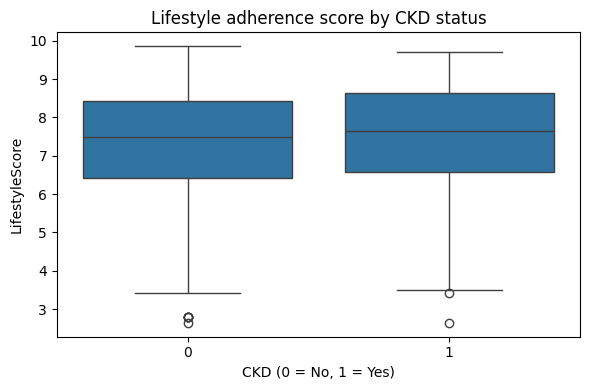


Mean LifestyleScore by CKD status:
                    mean    std  count
CKD (1-yes, 0-no)                     
0                  7.184  1.382   3614
1                  7.336  1.401    386


In [11]:
# LIFESTYLE ADHERENCE SCORE BY CKD STATUS

plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x=TARGET, y="LifestyleScore")
plt.xlabel("CKD (0 = No, 1 = Yes)")
plt.ylabel("LifestyleScore")
plt.title("Lifestyle adherence score by CKD status")
plt.tight_layout()
plt.show()

print("\nMean LifestyleScore by CKD status:")
print(df.groupby(TARGET)["LifestyleScore"].agg(["mean", "std", "count"]).round(3))




LOGISTIC REGRESSION COEFFICIENTS (LIFESTYLE FEATURES ONLY)
       feature      coef  abs_coef
   Insulin_use  0.483268  0.483268
     Walk_good  0.201117  0.201117
    Water_good -0.139238  0.139238
 Calorie_score -0.132220  0.132220
Low_Painkiller -0.115432  0.115432
      No_Zarda  0.110729  0.110729
    Med_follow  0.107389  0.107389
      No_Smoke -0.066163  0.066163
   Diet_follow -0.019747  0.019747
    Sleep_good  0.015746  0.015746

ROC-AUC using lifestyle features only: 0.659


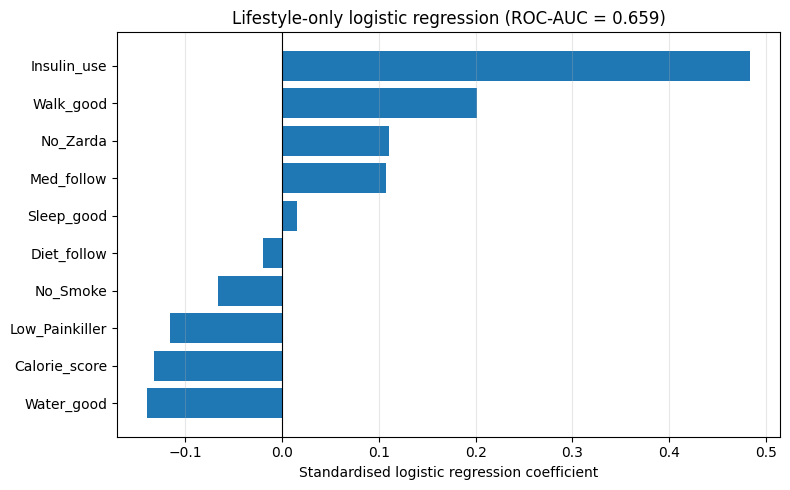

In [12]:
# LOGISTIC REGRESSION ON LIFESTYLE FEATURES ONLY

X = df[feature_cols].copy()
y = df[TARGET]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_scaled, y)

coef_df = pd.DataFrame({"feature": feature_cols, "coef": log_reg.coef_[0]})
coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False)

print("\n" + "=" * 64)
print("LOGISTIC REGRESSION COEFFICIENTS (LIFESTYLE FEATURES ONLY)")
print("=" * 64)
print(coef_df.to_string(index=False))

y_prob = log_reg.predict_proba(X_scaled)[:, 1]
auc = roc_auc_score(y, y_prob)
print(f"\nROC-AUC using lifestyle features only: {auc:.3f}")   # 0.659

plot_df = coef_df.sort_values("coef")
plt.figure(figsize=(8, 5))
plt.barh(plot_df["feature"], plot_df["coef"])
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Standardised logistic regression coefficient")
plt.title(f"Lifestyle-only logistic regression (ROC-AUC = {auc:.3f})")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()




SPEARMAN RANK CORRELATIONS WITH CKD (N = 4,000)
Variable                                                  rho           p  Sig.
Diabetic Year                                         +0.1249    2.18e-15   ***
Take Insulin (1-yes, 0-no)                            +0.1247     2.5e-15   ***
Age                                                   +0.0855    6.15e-08   ***
Urinary Infection (1-yes, 0-no)                       +0.0809    3.01e-07   ***
BMI                                                   +0.0714    6.19e-06   ***
Calorie Intake (per day)                              +0.0665    2.58e-05   ***
Walk Regularly (1-yes, 0-no)                          +0.0626    7.37e-05   ***
Weight (kg)                                           +0.0500     0.00155    **
Heart Disease (1-yes, 0-no)                           +0.0490     0.00193    **
Urination Properly (1-yes, 0-no)                      -0.0474     0.00272    **
Average Weight (kg)                                   +0.0439     0.005

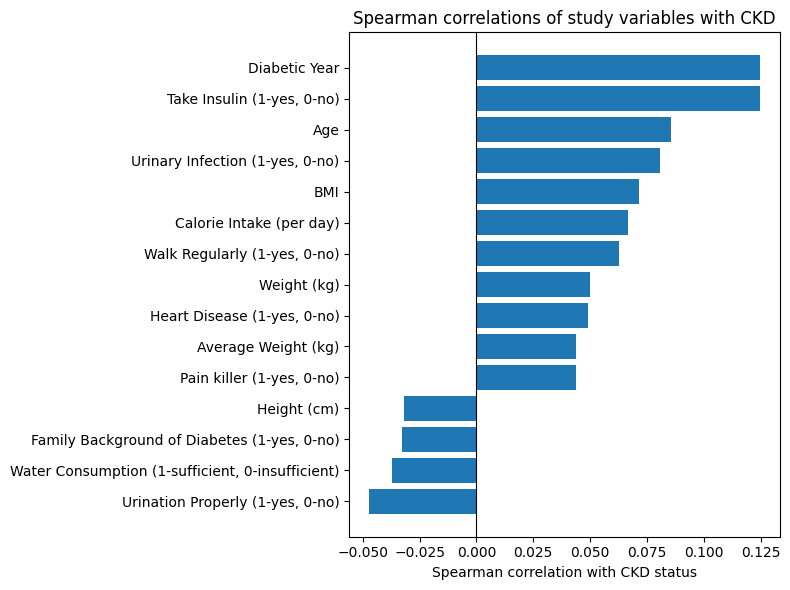

In [13]:
# SPEARMAN CORRELATIONS WITH CKD (N = 4,000)

rows = []
for c in df.columns:
    if c in [TARGET, "Patient ID"] or c in feature_cols or \
       c in ["LifestyleScore", "HighAdherence"]:
        continue
    x = df[c]
    if x.dtype == object:
        x = x.map({"F": 0, "M": 1})
    rho, p = spearmanr(x, df[TARGET])
    rows.append((c, rho, p))

corr = pd.DataFrame(rows, columns=["Variable", "rho", "p"])
corr["abs_rho"] = corr["rho"].abs()
corr = corr.sort_values("abs_rho", ascending=False)

print("\n" + "=" * 72)
print("SPEARMAN RANK CORRELATIONS WITH CKD (N = 4,000)")
print("=" * 72)
print(f"{'Variable':<52}{'rho':>9}{'p':>12}{'Sig.':>6}")
for _, r in corr.head(18).iterrows():
    print(f"{r['Variable']:<52}{r['rho']:>+9.4f}{r['p']:>12.3g}{stars(r['p']):>6}")

top = corr.head(15).sort_values("rho")
plt.figure(figsize=(8, 6))
plt.barh(top["Variable"], top["rho"])
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Spearman correlation with CKD status")
plt.title("Spearman correlations of study variables with CKD")
plt.tight_layout()
plt.show()